In [56]:
# Pydantic Models and Output Parser Imports
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from typing import List, Optional, Dict
from dotenv import load_dotenv
import os
# Load environment variables from .env file
load_dotenv()

True

In [57]:
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")  # Ensure the API key is set

In [58]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-2.5-pro')
output=model.invoke("hi")
print(output.content)

Hello! How can I help you today?


Assignment:

AI Travel Agent & Expense Planner(Purpose: Trip planning for any city worldwide with Realtime data.")

• Real-time weather information
• Top attractions and activities
• Hotel cost calculation (per day × total days)
• Currency conversion to user's native currency
• Complete itinerary generation
• Total expense calculation
• generate a summary of the entire output

user_input
  |
search attraction and activity
1. search attracation
2. search restaurant
3. search activity
4. search transportation
  |
search weather forcasting
1. get current weather
2. get weather forcast
  |
search hotel costs
1. search hotel
2. estimate the hotel cost
3. budget_range
  |
calculate total cost
1. add
2. multiply
3. calculated total cost
4. calcualte the daily budget
    |
currency_converion
1. get exchnage rate
2. convert currancy
    |
Itinery generation
1. get day plan
2. crete full itinery
    |
create Trip Summary
    |
Retun complete traval plan

Note: if you know the OOPS then design this entire system using object and class in modular fashion.


deadline is till next friday 9PM IST


 everyone you can submit the assignments in this form. MAke sure to have one GitHub link and put all the assignments there https://forms.gle/g8RZ4qx8yvNcih4B7


In [59]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [60]:
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [61]:
from langchain_google_genai import ChatGoogleGenerativeAI


llm=ChatGoogleGenerativeAI(model='gemini-2.5-pro')

In [62]:
llm.invoke("What is the capital of India?")  # Example usage

AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--17ddc4ea-9877-4135-8ffc-fde2b785861b-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 318, 'input_token_details': {'cache_read': 0}})

In [63]:
# Pydantic Models for Structured Outputs
class PlacesResponse(BaseModel):
    """Structured response for places and attractions"""
    attractions: List[str] = Field(description="List of top tourist attractions")
    restaurants: List[str] = Field(description="List of recommended restaurants")
    activities: List[str] = Field(description="List of recommended activities")
    transportation: List[str] = Field(description="List of transportation options")
    summary: str = Field(description="Brief summary of the place")

class WeatherResponse(BaseModel):
    """Structured response for weather information"""
    current_weather: str = Field(description="Current weather conditions")
    forecast: List[str] = Field(description="Weather forecast for travel dates")
    temperature_range: str = Field(description="Temperature range during travel")
    recommendations: List[str] = Field(description="Weather-based recommendations")

class DayPlan(BaseModel):
    """Structured response for a single day plan"""
    day_number: int = Field(description="Day number of the trip")
    morning_activities: List[str] = Field(description="Morning activities (9 AM - 12 PM)")
    afternoon_activities: List[str] = Field(description="Afternoon activities (12 PM - 6 PM)")
    evening_activities: List[str] = Field(description="Evening activities (6 PM - 10 PM)")
    restaurants: Dict[str, str] = Field(description="Meal recommendations {meal_type: restaurant}")
    transportation_tips: List[str] = Field(description="Transportation suggestions")
    weather_considerations: List[str] = Field(description="Weather-based tips")

class FullItinerary(BaseModel):
    """Structured response for complete itinerary"""
    destination: str = Field(description="Destination city")
    total_days: int = Field(description="Total number of days")
    daily_plans: List[DayPlan] = Field(description="Day-by-day detailed plans")
    emergency_contacts: List[str] = Field(description="Emergency contacts and information")
    local_tips: List[str] = Field(description="Local tips and cultural insights")
    budget_breakdown: Dict[str, str] = Field(description="Daily budget breakdown")

class TripSummary(BaseModel):
    """Structured response for trip summary"""
    destination: str = Field(description="Destination city")
    travel_dates: str = Field(description="Travel dates")
    total_cost: str = Field(description="Total estimated cost")
    key_highlights: List[str] = Field(description="Trip highlights")
    budget_breakdown: Dict[str, str] = Field(description="Cost breakdown by category")
    important_notes: List[str] = Field(description="Important travel notes")
    emergency_info: List[str] = Field(description="Emergency information")

class CompleteTravelPlan(BaseModel):
    """Structured response for complete travel plan"""
    trip_overview: str = Field(description="Trip overview and highlights")
    weather_forecast: WeatherResponse = Field(description="Weather information")
    places_info: PlacesResponse = Field(description="Places and attractions")
    itinerary: FullItinerary = Field(description="Complete itinerary")
    budget_summary: Dict[str, str] = Field(description="Budget breakdown")
    practical_info: List[str] = Field(description="Practical travel information")
    final_checklist: List[str] = Field(description="Final travel checklist")

In [64]:
## tools

from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()


from langchain_community.utilities import OpenWeatherMapAPIWrapper
os.environ["OPENWEATHERMAP_API_KEY"] =os.getenv("OWM_key")
weather_search = OpenWeatherMapAPIWrapper()
get_weather = weather_search.run



In [65]:
from langchain_core.tools import tool

# Initialize output parsers
places_parser = PydanticOutputParser(pydantic_object=PlacesResponse)
weather_parser = PydanticOutputParser(pydantic_object=WeatherResponse)
day_plan_parser = PydanticOutputParser(pydantic_object=DayPlan)
itinerary_parser = PydanticOutputParser(pydantic_object=FullItinerary)
trip_summary_parser = PydanticOutputParser(pydantic_object=TripSummary)
complete_plan_parser = PydanticOutputParser(pydantic_object=CompleteTravelPlan)

@tool
def get_places(place, dates) -> str:
    """
    Get comprehensive travel information for a city including attractions, restaurants, activities, and transportation.

    Args:
        place (str): The city to get travel information for.
        dates (str): The travel dates in the format 'YYYY-MM-DD to YYYY-MM-DD'.

    Returns:
        str: A JSON formatted string with structured travel information following PlacesResponse schema.

    Example:
        get_places("Paris", "2024-05-01 to 2024-05-07")
    """

    # Enhanced prompt with comprehensive formatting
    enhanced_prompt = f"""
You are a professional travel information specialist providing detailed destination data.

DESTINATION REQUEST:
Location: {place}
Travel Dates: {dates}

COMPREHENSIVE DESTINATION INFORMATION REQUIRED:

{places_parser.get_format_instructions()}

SPECIFIC REQUIREMENTS FOR EACH FIELD:

1. ATTRACTIONS (8-10 items):
   - Include iconic landmarks and must-see sites
   - Mix of historical, cultural, and entertainment venues
   - Include brief descriptions and significance
   - Consider seasonal availability during {dates}

2. RESTAURANTS (5-7 items):
   - Range from budget-friendly to fine dining
   - Include local cuisine specialties
   - Mix of restaurant types (casual, formal, street food, cafes)
   - Consider dietary restrictions and international options

3. ACTIVITIES (5-6 items):
   - Unique experiences specific to {place}
   - Mix of indoor and outdoor activities
   - Consider weather and seasonal factors
   - Include both guided and self-guided options

4. TRANSPORTATION (4-5 options):
   - Public transportation systems
   - Taxi and ride-sharing options
   - Walking and cycling opportunities
   - Airport/station connections
   - Local transportation tips

5. SUMMARY:
   - Compelling overview of what makes {place} special
   - Highlight unique cultural aspects
   - Mention best times to visit attractions
   - Include any special considerations for {dates}

QUALITY STANDARDS:
All information must be current and accurate
Provide practical, actionable recommendations
Include local insights and tips
Consider the travel dates for seasonal recommendations
Format as valid JSON matching the schema exactly

Generate detailed, practical travel information in the exact JSON format specified.
"""

    try:
        # Search for comprehensive information
        search_query = f"travel guide {place} best attractions restaurants activities transportation {dates}"
        search_results = search.invoke(search_query)

        # Combine prompt with search results
        complete_prompt = enhanced_prompt + f"\n\nREAL-TIME SEARCH DATA:\n{search_results}\n\nUse this data to provide accurate, current information."

        # Generate structured response
        structured_response = llm.invoke(complete_prompt)

        # Parse and validate response
        try:
            parsed_response = places_parser.parse(structured_response.content)
            return parsed_response.model_dump_json(indent=2)

        except Exception as parse_error:
            print(f" Places parsing fallback activated: {parse_error}")
            # Enhanced fallback with more detailed information
            fallback_response = PlacesResponse(
                attractions=[
                    f"Historic landmarks and monuments in {place}",
                    f"Main cultural museums and galleries",
                    f"Popular shopping districts and markets",
                    f"Scenic viewpoints and parks",
                    f"Religious and architectural sites",
                    f"Entertainment and nightlife areas",
                    f"Waterfront or natural attractions",
                    f"Local neighborhoods worth exploring"
                ],
                restaurants=[
                    f"Traditional {place} cuisine restaurants",
                    f"International dining options",
                    f"Local street food and market vendors",
                    f"Fine dining establishments",
                    f"Casual cafes and bistros",
                    f"Family-friendly restaurants",
                    f"Vegetarian and specialty diet options"
                ],
                activities=[
                    f"Walking tours of {place} city center",
                    f"Cultural performances and shows",
                    f"Local cooking or craft classes",
                    f"Boat tours or scenic rides",
                    f"Shopping at local markets",
                    f"Photography tours of iconic sites"
                ],
                transportation=[
                    f"Public metro/bus system in {place}",
                    f"Taxi and ride-sharing services",
                    f"Bicycle rentals and bike tours",
                    f"Walking routes between attractions",
                    f"Airport and train station connections"
                ],
                summary=f"{place} offers a rich blend of cultural heritage, culinary delights, and diverse attractions. During {dates}, visitors can explore historic landmarks, enjoy local cuisine, and experience the unique character of this destination. The city provides excellent transportation options for easy navigation between attractions."
            )
            return fallback_response.model_dump_json(indent=2)

    except Exception as e:
        print(f" Complete places tool fallback: {e}")
        # Basic fallback response
        basic_response = PlacesResponse(
            attractions=[f"Major attractions in {place}"],
            restaurants=[f"Local restaurants in {place}"],
            activities=[f"Popular activities in {place}"],
            transportation=[f"Transportation options in {place}"],
            summary=f"Travel information for {place} during {dates}"
        )
        return basic_response.model_dump_json(indent=2)

@tool
def get_weather(city: str, dates: str) -> str:
    """
    Get comprehensive weather information for a city and travel dates with detailed forecasts and recommendations.

    Args:
        city (str): The city to get weather information for.
        dates (str): The travel dates in the format 'YYYY-MM-DD to YYYY-MM-DD'.

    Returns:
        str: A JSON formatted string with structured weather information following WeatherResponse schema.

    Example:
        get_weather("Paris", "2024-05-01 to 2024-05-07")
    """

    # Enhanced weather prompt with comprehensive formatting
    enhanced_weather_prompt = f"""
You are a professional meteorological consultant providing detailed weather information for travelers.

WEATHER REQUEST:
Location: {city}
Travel Period: {dates}

COMPREHENSIVE WEATHER ANALYSIS REQUIRED:

{weather_parser.get_format_instructions()}

SPECIFIC REQUIREMENTS FOR EACH FIELD:

1. CURRENT_WEATHER:
   - Current temperature, humidity, wind conditions
   - Current weather type (sunny, cloudy, rainy, etc.)
   - Visibility and air quality if relevant
   - "Feels like" temperature and comfort level

2. FORECAST (Daily breakdown):
   - Day-by-day weather for the travel period
   - High and low temperatures for each day
   - Precipitation probability and amounts
   - Wind conditions and any weather alerts
   - Best and worst weather days during the period

3. TEMPERATURE_RANGE:
   - Overall temperature range for the travel period
   - Seasonal context (typical for this time of year)
   - Day vs. night temperature variations
   - Heat index or wind chill considerations

4. RECOMMENDATIONS (5-7 items):
   - Specific clothing recommendations for the weather
   - Activity suggestions based on weather conditions
   - Indoor alternatives for poor weather days
   - Best times of day for outdoor activities
   - Any weather-related travel precautions
   - Packing suggestions for the expected conditions

QUALITY STANDARDS:
✅ Use real-time weather data when available
✅ Provide practical, actionable advice
✅ Consider travel-specific weather needs
✅ Include both optimistic and cautionary guidance
✅ Format as valid JSON matching the schema exactly

Generate comprehensive weather information in the exact JSON format specified.
"""

    try:
        # Get weather information from API
        weather_query = f"Weather forecast for {city} {dates}"
        weather_info = weather_search.invoke(weather_query)

        # Combine prompt with weather data
        complete_weather_prompt = enhanced_weather_prompt + f"\n\nREAL-TIME WEATHER DATA:\n{weather_info}\n\nUse this data to provide accurate weather forecasts and recommendations."

        # Generate structured response
        structured_response = llm.invoke(complete_weather_prompt)

        try:
            parsed_response = weather_parser.parse(structured_response.content)
            return parsed_response.model_dump_json(indent=2)

        except Exception as parse_error:
            print(f"🔄 Weather parsing fallback activated: {parse_error}")
            # Enhanced fallback with seasonal information
            fallback_response = WeatherResponse(
                current_weather=f"Current weather conditions in {city} - check local weather services for real-time updates",
                forecast=[
                    f"Day 1: Variable conditions expected",
                    f"Day 2-3: Typical seasonal weather for {city}",
                    f"Day 4-5: Monitor local forecasts for accuracy",
                    f"Weekend: Weather patterns may vary",
                    f"Overall period: Generally seasonal conditions expected"
                ],
                temperature_range=f"Seasonal temperature range typical for {city} during this period - check current forecasts",
                recommendations=[
                    "Pack layered clothing for temperature variations",
                    "Bring waterproof jacket for unexpected rain",
                    "Check daily weather before planning outdoor activities",
                    "Have indoor backup plans for inclement weather",
                    "Wear comfortable walking shoes suitable for various conditions",
                    "Carry umbrella or rain protection",
                    "Monitor local weather apps for real-time updates"
                ]
            )
            return fallback_response.model_dump_json(indent=2)

    except Exception as e:
        print(f"🚨 Complete weather tool fallback: {e}")
        # Basic fallback response
        basic_response = WeatherResponse(
            current_weather=f"Weather information for {city} - please check local weather services",
            forecast=[f"Check local weather forecast for {dates}"],
            temperature_range="Consult local weather services for accurate temperature ranges",
            recommendations=[
                "Pack versatile clothing for changing conditions",
                "Check weather forecasts daily during travel",
                "Have indoor and outdoor activity options ready"
            ]
        )
        return basic_response.model_dump_json(indent=2)


@tool
def add(a: float, b: float) -> float:
    """
    Add two numbers together.

    Args:
        a (float): The first number to add.
        b (float): The second number to add.

    Returns:
        float: The sum of a and b.

    Example:
        add(2.5, 3.0) -> 5.5
    """
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers.

    Args:
        a (float): The first number to multiply.
        b (float): The second number to multiply.

    Returns:
        float: The product of a and b.

    Example:
        multiply(2.5, 3.0) -> 7.5
    """
    return a * b

In [66]:
@tool
def calculate_total_cost(per_day_cost: float, num_days: int) -> float:
    """
    Calculate the total cost for a trip.

    Args:
        per_day_cost (float): The estimated cost per day for accommodation, food, and other expenses.
        num_days (int): The total number of days for the trip.

    Returns:
        float: The total cost for the trip, calculated as per_day_cost multiplied by num_days.
    """
    return per_day_cost * num_days

@tool
def calculate_daily_budget(total_cost: float, num_days: int) -> float:
    """
    Calculate the daily budget for a trip.

    Args:
        total_cost (float): The total estimated cost for the entire trip.
        num_days (int): The total number of days for the trip.

    Returns:
        float: The average daily budget, calculated as total_cost divided by num_days.
               Returns 0 if num_days is less than or equal to 0.
    """
    return total_cost / num_days if num_days > 0 else 0

In [67]:
from langchain_core.tools import tool
import requests

@tool
def get_exchange_rate(from_currency: str, to_currency: str) -> float:
    """
    Get the current exchange rate between two currencies.

    Args:
        from_currency (str): The source currency code (e.g., 'USD', 'EUR', 'INR').
        to_currency (str): The target currency code (e.g., 'USD', 'EUR', 'INR').

    Returns:
        float: The exchange rate from source to target currency.

    Example:
        get_exchange_rate("USD", "INR") -> 83.25
    """
    try:
        # Using a free API for exchange rates
        url = f"https://api.exchangerate-api.com/v4/latest/{from_currency.upper()}"
        response = requests.get(url)
        data = response.json()

        if to_currency.upper() in data['rates']:
            return data['rates'][to_currency.upper()]
        else:
            return 1.0  # Return 1 if currency not found
    except:
        # Fallback: use DuckDuckGo search for exchange rate
        query = f"exchange rate {from_currency} to {to_currency}"
        search_result = search.invoke(query)
        return f"Exchange rate info: {search_result}"


@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> float:
    """
    Convert an amount from one currency to another.

    Args:
        amount (float): The amount to convert.
        from_currency (str): The source currency code (e.g., 'USD', 'EUR', 'INR').
        to_currency (str): The target currency code (e.g., 'USD', 'EUR', 'INR').

    Returns:
        float: The converted amount in the target currency.

    Example:
        convert_currency(100, "USD", "INR") -> 8325.0
    """
    try:
        # Get exchange rate
        url = f"https://api.exchangerate-api.com/v4/latest/{from_currency.upper()}"
        response = requests.get(url)
        data = response.json()

        if to_currency.upper() in data['rates']:
            exchange_rate = data['rates'][to_currency.upper()]
            converted_amount = amount * exchange_rate
            return round(converted_amount, 2)
        else:
            return amount  # Return original amount if conversion fails
    except:
        # Fallback calculation using search
        query = f"convert {amount} {from_currency} to {to_currency}"
        search_result = search.invoke(query)
        return f"Conversion result: {search_result}"

In [68]:
@tool
def currency_conversion_search(amount: float, from_currency: str, to_currency: str) -> str:
    """
    Get currency conversion using web search.

    Args:
        amount (float): The amount to convert.
        from_currency (str): The source currency code.
        to_currency (str): The target currency code.

    Returns:
        str: Currency conversion information from web search.

    Example:
        currency_conversion_search(100, "USD", "EUR")
    """
    query = f"convert {amount} {from_currency} to {to_currency} exchange rate"
    search_result = search.invoke(query)
    return search_result

In [69]:
@tool
def get_day_plan(city: str, day_number: int, attractions: str, weather: str) -> str:
    """
    Generate a detailed day plan for a specific day of travel.

    Args:
        city (str): The city being visited.
        day_number (int): The day number of the trip (e.g., 1, 2, 3).
        attractions (str): List of attractions and activities available.
        weather (str): Weather information for that day.

    Returns:
        str: A JSON formatted string with detailed day plan.

    Example:
        get_day_plan("Paris", 1, "Eiffel Tower, Louvre Museum", "Sunny, 22°C")
    """
    day_plan_prompt = f"""
    Create a detailed day {day_number} itinerary for {city}.

    Available attractions and activities: {attractions}
    Weather conditions: {weather}

    Please provide a comprehensive day plan in the specified JSON format:

    {day_plan_parser.get_format_instructions()}

    Include:
    - Morning activities (9:00 AM - 12:00 PM) - 2-3 activities
    - Afternoon activities (12:00 PM - 6:00 PM) - 2-3 activities
    - Evening activities (6:00 PM - 10:00 PM) - 1-2 activities
    - Restaurant recommendations for breakfast, lunch, and dinner
    - Transportation suggestions between locations
    - Weather-specific tips and recommendations

    Make the plan realistic and enjoyable.
    """

    try:
        structured_response = llm.invoke(day_plan_prompt)

        try:
            parsed_response = day_plan_parser.parse(structured_response.content)
            return parsed_response.model_dump_json(indent=2)
        except Exception:
            # Fallback response
            fallback_response = DayPlan(
                day_number=day_number,
                morning_activities=[f"Morning sightseeing in {city}", "Visit main attraction"],
                afternoon_activities=[f"Afternoon exploration", "Local dining experience"],
                evening_activities=[f"Evening leisure activities"],
                restaurants={"breakfast": "Local cafe", "lunch": "Traditional restaurant", "dinner": "Popular local eatery"},
                transportation_tips=["Use public transport", "Walking between nearby attractions"],
                weather_considerations=["Check weather conditions", "Dress appropriately"]
            )
            return fallback_response.model_dump_json(indent=2)

    except Exception:
        # Complete fallback
        fallback_response = DayPlan(
            day_number=day_number,
            morning_activities=[f"Explore {city} morning attractions"],
            afternoon_activities=[f"Afternoon activities in {city}"],
            evening_activities=[f"Evening entertainment"],
            restaurants={"breakfast": "Local breakfast spot", "lunch": "Lunch venue", "dinner": "Dinner restaurant"},
            transportation_tips=["Plan transportation routes"],
            weather_considerations=["Weather-appropriate activities"]
        )
        return fallback_response.model_dump_json(indent=2)

In [70]:
@tool
def create_full_itinerary(city: str, dates: str, num_days: int, attractions: str, weather: str) -> str:
    """
    Create a complete itinerary for the entire trip.

    Args:
        city (str): The destination city.
        dates (str): Travel dates in format 'YYYY-MM-DD to YYYY-MM-DD'.
        num_days (int): Total number of days for the trip.
        attractions (str): All available attractions, restaurants, and activities.
        weather (str): Weather forecast for the travel period.

    Returns:
        str: A JSON formatted string with complete itinerary.

    Example:
        create_full_itinerary("Paris", "2024-05-01 to 2024-05-07", 7, "attractions list", "weather info", "$2000")
    """
    itinerary_prompt = f"""
    Create a comprehensive {num_days}-day travel itinerary for {city} from {dates}.

    Available information:
    - Attractions and activities: {attractions}
    - Weather forecast: {weather}

    Please provide a complete itinerary in the specified JSON format:

    {itinerary_parser.get_format_instructions()}

    Include:
    - Detailed day-by-day plans for all {num_days} days
    - Must-visit attractions prioritized by importance
    - Restaurant recommendations for each day
    - Transportation plans between locations
    - Budget breakdown per day and category
    - Alternative indoor activities for bad weather
    - Local tips and cultural insights
    - Emergency contacts and important information

    Make the itinerary practical, enjoyable, and within budget.
    """


    structured_response = llm.invoke(itinerary_prompt)

    return structured_response.content

In [71]:
@tool
def create_trip_summary(
    city: str,
    dates: str,
    total_cost: float,
    currency: str,
    attractions: str,
    weather: str,
    itinerary: str,
    hotel_info: str
) -> str:
    """
    Create a comprehensive trip summary with all travel details.

    Args:
        city (str): The destination city.
        dates (str): Travel dates in format 'YYYY-MM-DD to YYYY-MM-DD'.
        total_cost (float): Total estimated cost for the trip.
        currency (str): Currency for the cost display.
        attractions (str): Summary of attractions and activities.
        weather (str): Weather forecast summary.
        itinerary (str): Complete itinerary details.
        hotel_info (str): Hotel booking and cost information.

    Returns:
        str: A JSON formatted string with comprehensive trip summary.

    Example:
        create_trip_summary("Paris", "2024-05-01 to 2024-05-07", 2000, "USD", "attractions", "weather", "itinerary", "hotel")
    """
    summary_prompt = f"""
    Create a comprehensive trip summary for:

    DESTINATION: {city}
    TRAVEL DATES: {dates}
    TOTAL BUDGET: {total_cost} {currency}

    ATTRACTIONS & ACTIVITIES: {attractions}
    WEATHER FORECAST: {weather}
    ACCOMMODATION: {hotel_info}
    COMPLETE ITINERARY: {itinerary}

    Please format this into a structured trip summary using the following JSON format:

    {trip_summary_parser.get_format_instructions()}

    Include:
    1. Trip Overview with key highlights
    2. Budget Breakdown by category
    3. Key Highlights and must-see attractions
    4. Weather Considerations and recommendations
    5. Important Notes for travelers
    6. Emergency Information and contacts

    Make it a complete, professional travel document.
    """

    try:
        structured_response = llm.invoke(summary_prompt)

        try:
            parsed_response = trip_summary_parser.parse(structured_response.content)
            return parsed_response.model_dump_json(indent=2)
        except Exception:
            # Fallback response
            fallback_response = TripSummary(
                destination=city,
                travel_dates=dates,
                total_cost=f"{total_cost} {currency}",
                key_highlights=[f"Visit top attractions in {city}", "Experience local culture", "Enjoy local cuisine"],
                budget_breakdown={
                    "accommodation": f"{total_cost * 0.4:.2f} {currency}",
                    "food": f"{total_cost * 0.3:.2f} {currency}",
                    "activities": f"{total_cost * 0.2:.2f} {currency}",
                    "transport": f"{total_cost * 0.1:.2f} {currency}"
                },
                important_notes=["Check passport validity", "Get travel insurance", "Research local customs"],
                emergency_info=["Local emergency services", "Embassy contacts", "Travel insurance details"]
            )
            return fallback_response.model_dump_json(indent=2)

    except Exception:
        # Complete fallback
        fallback_response = TripSummary(
            destination=city,
            travel_dates=dates,
            total_cost=f"{total_cost} {currency}",
            key_highlights=[f"Trip to {city}"],
            budget_breakdown={"total": f"{total_cost} {currency}"},
            important_notes=["Travel preparation required"],
            emergency_info=["Research emergency contacts"]
        )
        return fallback_response.model_dump_json(indent=2)


# Alternative: Simple summary tool using search
@tool
def generate_trip_summary_search(trip_data: str) -> str:
    """
    Generate a trip summary using web search for additional travel tips.

    Args:
        trip_data (str): All collected trip information as a formatted string.

    Returns:
        str: A comprehensive trip summary with additional travel tips.

    Example:
        generate_trip_summary_search("Trip to Paris, 7 days, $2000 budget...")
    """
    summary_prompt = f"""
    Generate a comprehensive trip summary based on the following trip data:
    {trip_data}

    Please provide the summary in this JSON format:

    {trip_summary_parser.get_format_instructions()}

    Include practical travel tips and important reminders.
    """

    try:
        # Search for additional tips
        search_result = search.invoke(f"travel tips and advice for {trip_data}")

        # Generate structured summary
        structured_response = llm.invoke(summary_prompt + f"\n\nAdditional tips: {search_result}")

        try:
            parsed_response = trip_summary_parser.parse(structured_response.content)
            return parsed_response.model_dump_json(indent=2)
        except Exception:
            # Simple fallback
            return f"""
            TRIP SUMMARY
            ============
            {trip_data}

            ADDITIONAL TRAVEL TIPS:
            {search_result}

            FINAL CHECKLIST:
            - Passport/ID documents
            - Travel insurance
            - Local currency
            - Emergency contacts
            - Accommodation confirmations
            - Transportation bookings
            """

    except Exception:
        return f"Trip Summary: {trip_data}"

In [72]:
@tool
def generate_complete_travel_plan(
    city: str,
    dates: str,
    num_days: int,
    budget: float,
    currency: str,
    user_preferences: str = ""
) -> str:
    """
    Create a comprehensive travel plan using enhanced Pydantic formatting for all fields.

    Args:
        city (str): Destination city
        dates (str): Travel dates in format 'YYYY-MM-DD to YYYY-MM-DD'
        num_days (int): Total number of days for the trip
        budget (float): Total budget for the trip
        currency (str): Currency code (e.g., 'USD', 'EUR', 'INR')
        user_preferences (str): User preferences and interests

    Returns:
        str: A JSON formatted string with complete travel plan following CompleteTravelPlan schema

    Example:
        generate_complete_travel_plan("Paris", "2024-05-01 to 2024-05-07", 7, 2000, "USD", "culture, food, museums")
    """

    # Enhanced comprehensive travel planning prompt
    enhanced_complete_prompt = f"""
You are an expert AI Travel Agent & Expense Planner creating the ultimate comprehensive travel plan.

TRAVEL REQUEST ANALYSIS:
🎯 Destination: {city}
📅 Travel Dates: {dates}
⏰ Duration: {num_days} days
💰 Total Budget: {budget} {currency}
💰 Daily Budget: {budget/num_days:.2f} {currency}
🎨 User Preferences: {user_preferences if user_preferences else "General travel and cultural experiences"}

COMPREHENSIVE TRAVEL PLAN SCHEMA:

{complete_plan_parser.get_format_instructions()}

DETAILED REQUIREMENTS FOR EACH FIELD:

1. TRIP_OVERVIEW (Comprehensive summary):
   - Destination highlights and what makes {city} unique
   - Best aspects of visiting during {dates}
   - Cultural significance and local characteristics
   - Why this trip duration ({num_days} days) is ideal
   - Special events or seasonal attractions during travel dates

2. WEATHER_FORECAST (Complete WeatherResponse object):
   - Current weather conditions in {city}
   - Day-by-day forecast for {dates}
   - Temperature ranges and seasonal patterns
   - Detailed clothing and activity recommendations
   - Weather-specific travel tips

3. PLACES_INFO (Complete PlacesResponse object):
   - Top 10 must-visit attractions with descriptions
   - 7-8 recommended restaurants covering various cuisines and budgets
   - 6-7 unique activities and experiences
   - Comprehensive transportation options
   - Compelling destination summary

4. ITINERARY (Complete FullItinerary object):
   - Detailed daily plans for all {num_days} days
   - Each day includes morning, afternoon, evening activities
   - Restaurant recommendations for each meal
   - Transportation tips between locations
   - Weather considerations for each day
   - Emergency contacts and local information
   - Cultural tips and local customs
   - Detailed budget breakdown

5. BUDGET_SUMMARY (Detailed breakdown):
   - Total Budget: {budget} {currency}
   - Daily Budget: {budget/num_days:.2f} {currency}
   - Accommodation (40%): {budget * 0.4:.2f} {currency}
   - Food & Dining (30%): {budget * 0.3:.2f} {currency}
   - Activities & Attractions (20%): {budget * 0.2:.2f} {currency}
   - Transportation (10%): {budget * 0.1:.2f} {currency}
   - Contingency recommendations
   - Money-saving tips

6. PRACTICAL_INFO (10+ essential items):
   - Visa and passport requirements
   - Travel insurance recommendations
   - Currency exchange and payment methods
   - Local customs and cultural etiquette
   - Health and safety considerations
   - Communication and connectivity
   - Local laws and regulations
   - Tipping customs and practices
   - Emergency procedures
   - Language basics and useful phrases

7. FINAL_CHECKLIST (15+ items):
   - Complete pre-departure checklist
   - Essential documents needed
   - Packing recommendations for {dates} weather
   - Technology and connectivity preparations
   - Health and medication considerations
   - Financial preparations
   - Travel app recommendations
   - Emergency contact preparations
   - Cultural preparation items
   - Day-of-travel essentials

QUALITY STANDARDS:
✅ All nested objects must follow their respective schemas exactly
✅ Provide specific, actionable recommendations
✅ Include real-world practical advice
✅ Consider the user preferences: {user_preferences}
✅ Ensure budget calculations are accurate
✅ Include local cultural insights
✅ Format as valid JSON matching the schema perfectly

SPECIAL CONSIDERATIONS:
- Tailor recommendations to {user_preferences}
- Optimize for {num_days}-day duration
- Respect the {budget} {currency} budget constraint
- Consider seasonal factors for {dates}
- Include accessibility information where relevant

Generate a comprehensive, professional travel plan in the exact JSON format specified above.
"""

    try:
        # Generate comprehensive travel plan
        response = llm.invoke(enhanced_complete_prompt)

        try:
            # Parse structured response with enhanced validation
            parsed_response = complete_plan_parser.parse(response.content)
            return parsed_response.model_dump_json(indent=2)

        except Exception as parse_error:
            print(f"🔄 Complete plan parsing fallback activated: {parse_error}")

            # Enhanced fallback: Create comprehensive structured response
            weather_info = WeatherResponse(
                current_weather=f"Current weather in {city} - typically seasonal conditions",
                forecast=[
                    f"Day 1-2: Generally pleasant weather expected",
                    f"Day 3-4: Variable conditions typical for {city}",
                    f"Day 5-{num_days}: Seasonal weather patterns",
                    f"Overall: Weather appropriate for {dates} travel period"
                ],
                temperature_range=f"Seasonal temperatures for {city} during {dates}",
                recommendations=[
                    "Pack layered clothing for temperature variations",
                    "Include rain protection for unexpected weather",
                    "Comfortable walking shoes essential",
                    "Check daily forecasts for activity planning",
                    "Have indoor backup activities ready"
                ]
            )

            places_info = PlacesResponse(
                attractions=[
                    f"Historic city center and main landmarks of {city}",
                    f"Premier museums and cultural institutions",
                    f"Iconic architectural sites and monuments",
                    f"Beautiful parks and scenic viewpoints",
                    f"Vibrant shopping districts and markets",
                    f"Entertainment and cultural venues",
                    f"Religious and spiritual sites",
                    f"Local neighborhoods with authentic character",
                    f"Waterfront or natural attractions",
                    f"Photography-worthy locations and hidden gems"
                ],
                restaurants=[
                    f"Traditional {city} cuisine establishments",
                    f"International fine dining options",
                    f"Local street food and market vendors",
                    f"Cozy cafes and bistros",
                    f"Family-friendly restaurants",
                    f"Vegetarian and dietary-specific options",
                    f"Rooftop or scenic dining venues",
                    f"Budget-friendly local favorites"
                ],
                activities=[
                    f"Guided walking tours of {city} highlights",
                    f"Cultural performances and local shows",
                    f"Hands-on workshops or cooking classes",
                    f"Scenic boat or transport tours",
                    f"Local market and shopping experiences",
                    f"Photography tours of iconic locations",
                    f"Evening entertainment and nightlife"
                ],
                transportation=[
                    f"Comprehensive public transit system",
                    f"Taxi and ride-sharing services",
                    f"Bicycle rentals and cycling routes",
                    f"Walking paths between major attractions",
                    f"Airport and transport hub connections"
                ],
                summary=f"{city} offers an exceptional blend of cultural heritage, culinary excellence, and diverse attractions. During {dates}, visitors can explore rich history, enjoy world-class dining, and experience the unique atmosphere that makes this destination special. The city provides excellent infrastructure for comfortable travel and exploration."
            )

            # Create detailed daily plans
            daily_plans = []
            for day in range(1, num_days + 1):
                day_plan = DayPlan(
                    day_number=day,
                    morning_activities=[
                        f"Day {day}: Morning exploration of major {city} attraction",
                        f"Visit historic landmark or cultural site",
                        f"Coffee and pastry at local cafe"
                    ],
                    afternoon_activities=[
                        f"Day {day}: Afternoon cultural or museum experience",
                        f"Lunch at recommended local restaurant",
                        f"Walking tour of distinctive neighborhood"
                    ],
                    evening_activities=[
                        f"Day {day}: Evening dining and entertainment",
                        f"Sunset viewing or scenic evening walk"
                    ],
                    restaurants={
                        "breakfast": f"Day {day} morning cafe or hotel breakfast",
                        "lunch": f"Day {day} traditional {city} cuisine restaurant",
                        "dinner": f"Day {day} evening dining experience"
                    },
                    transportation_tips=[
                        f"Use public transport for efficient Day {day} travel",
                        f"Walking recommended between nearby attractions",
                        f"Consider taxi for evening activities"
                    ],
                    weather_considerations=[
                        f"Check Day {day} weather for outdoor activities",
                        f"Have indoor alternatives ready",
                        f"Dress appropriately for seasonal conditions"
                    ]
                )
                daily_plans.append(day_plan)

            itinerary = FullItinerary(
                destination=city,
                total_days=num_days,
                daily_plans=daily_plans,
                emergency_contacts=[
                    f"Local emergency services in {city}",
                    f"Tourist police and assistance",
                    f"Embassy or consulate contact",
                    f"Travel insurance emergency number",
                    f"Hotel or accommodation contact"
                ],
                local_tips=[
                    f"Respect local customs and traditions in {city}",
                    f"Learn basic greetings in the local language",
                    f"Understand local dining and tipping etiquette",
                    f"Best areas for safe evening activities",
                    f"Local transportation etiquette and tips",
                    f"Cultural dos and don'ts for visitors",
                    f"Best times to visit popular attractions"
                ],
                budget_breakdown={
                    "total_budget": f"{budget} {currency}",
                    "daily_budget": f"{budget/num_days:.2f} {currency}",
                    "accommodation": f"{budget * 0.4:.2f} {currency} (40%)",
                    "food_dining": f"{budget * 0.3:.2f} {currency} (30%)",
                    "activities": f"{budget * 0.2:.2f} {currency} (20%)",
                    "transportation": f"{budget * 0.1:.2f} {currency} (10%)"
                }
            )

            comprehensive_plan = CompleteTravelPlan(
                trip_overview=f"Comprehensive {num_days}-day travel experience in {city} from {dates}. This carefully planned itinerary balances must-see attractions, cultural experiences, and local cuisine within a {budget} {currency} budget. Perfect for travelers interested in {user_preferences if user_preferences else 'diverse cultural experiences'}.",
                weather_forecast=weather_info,
                places_info=places_info,
                itinerary=itinerary,
                budget_summary={
                    "total_budget": f"{budget} {currency}",
                    "daily_budget": f"{budget/num_days:.2f} {currency}",
                    "accommodation_40_percent": f"{budget * 0.4:.2f} {currency}",
                    "food_dining_30_percent": f"{budget * 0.3:.2f} {currency}",
                    "activities_20_percent": f"{budget * 0.2:.2f} {currency}",
                    "transportation_10_percent": f"{budget * 0.1:.2f} {currency}",
                    "currency_tips": f"Exchange to local currency for best rates",
                    "contingency": f"Keep 5-10% extra for unexpected expenses"
                },
                practical_info=[
                    f"Check passport validity (6+ months remaining)",
                    f"Obtain comprehensive travel insurance",
                    f"Research visa requirements for {city}",
                    f"Notify banks of international travel",
                    f"Download offline maps and translation apps",
                    f"Learn basic local language phrases",
                    f"Understand local emergency numbers",
                    f"Research local customs and etiquette",
                    f"Check health and vaccination requirements",
                    f"Arrange international phone/data plan",
                    f"Prepare copies of important documents",
                    f"Research local tipping and payment customs"
                ],
                final_checklist=[
                    "✓ Passport and required visas",
                    "✓ Travel insurance documentation",
                    "✓ Flight tickets and itinerary",
                    "✓ Accommodation confirmations",
                    "✓ Travel insurance and medical info",
                    "✓ Bank cards and local currency",
                    "✓ Emergency contact information",
                    "✓ Copies of important documents",
                    "✓ Weather-appropriate clothing",
                    "✓ Comfortable walking shoes",
                    "✓ Phone, chargers, and adapters",
                    "✓ Medications and health items",
                    "✓ Camera and travel accessories",
                    "✓ Guidebooks or travel apps",
                    "✓ Entertainment for travel time"
                ]
            )

            return comprehensive_plan.model_dump_json(indent=2)

    except Exception as e:
        print(f"🚨 Complete travel plan ultimate fallback: {e}")

        # Ultimate fallback response
        basic_plan = CompleteTravelPlan(
            trip_overview=f"Travel plan for {city} from {dates} - {num_days} days with {budget} {currency} budget",
            weather_forecast=WeatherResponse(
                current_weather=f"Check local weather for {city}",
                forecast=[f"Monitor weather conditions during {dates}"],
                temperature_range="Seasonal temperatures expected",
                recommendations=["Pack versatile clothing", "Check weather daily"]
            ),
            places_info=PlacesResponse(
                attractions=[f"Research top attractions in {city}"],
                restaurants=[f"Explore local dining in {city}"],
                activities=[f"Discover activities in {city}"],
                transportation=[f"Use local transportation options"],
                summary=f"Explore the highlights of {city}"
            ),
            itinerary=FullItinerary(
                destination=city,
                total_days=num_days,
                daily_plans=[],
                emergency_contacts=[f"Research emergency contacts for {city}"],
                local_tips=[f"Learn about local customs in {city}"],
                budget_breakdown={"total": f"{budget} {currency}"}
            ),
            budget_summary={
                "total": f"{budget} {currency}",
                "daily": f"{budget/num_days:.2f} {currency}"
            },
            practical_info=[f"Research travel requirements for {city}"],
            final_checklist=[f"Prepare for travel to {city}"]
        )

        return basic_plan.model_dump_json(indent=2)

In [73]:
tools = [
    get_places,
    weather_search.run,
    add,
    multiply,
    calculate_total_cost,
    calculate_daily_budget,
    get_exchange_rate,
    convert_currency,
    currency_conversion_search,
    get_day_plan,
    create_full_itinerary,
    create_trip_summary,
    generate_trip_summary_search,
    generate_complete_travel_plan
]

In [74]:
llm_with_tools = llm.bind_tools(tools)

In [75]:
from langchain_core.messages import   HumanMessage
from langgraph.graph import  MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [88]:
def function_1(state: MessagesState) -> MessagesState:
    """
    Enhanced LLM function with Pydantic-based structured output processing.

    Args:
        state (MessagesState): The current state containing user messages and context.

    Returns:
        MessagesState: Updated state with AIMessage or tool call response in structured JSON format.

    Details:
        - Accepts a MessagesState dict with key "messages" containing user queries.
        - Prepends a detailed system prompt for travel planning.
        - Invokes the LLM with tools to generate structured travel plan outputs.
        - Ensures all responses follow Pydantic model schemas and include all required fields.
        - Returns a new MessagesState dict with the AI response or fallback message.
        - if budget is not provided, calculate actual budget based on per_day_cost and num_days.
    """
    user_question = state["messages"]

    SYSTEM_PROMPT = """You are a professional AI Travel Agent & Expense Planner with expertise in creating comprehensive travel plans.

    CORE MISSION: Create detailed, structured travel plans using available tools to gather real-time data and generate complete itineraries with budget calculations.

    STRUCTURED OUTPUT REQUIREMENT:
    - All responses must use the provided tools to generate structured JSON outputs
    - Follow Pydantic model schemas exactly for consistent data format
    - Ensure all required fields are populated with meaningful data
    - Use fallback values when real-time data is unavailable

    AVAILABLE TOOLS & THEIR PURPOSES:

    🏛️ PLACES & ATTRACTIONS:
    - get_places(place, dates): Get attractions, restaurants, activities, transportation
      → Returns: PlacesResponse JSON with attractions, restaurants, activities, transportation, summary

    🌤️ WEATHER INFORMATION:
    - get_weather(city, dates): Get weather forecasts and recommendations
      → Returns: WeatherResponse JSON with current_weather, forecast, temperature_range, recommendations

    💰 BUDGET CALCULATIONS:
    - calculate_total_cost(per_day_cost, num_days): Calculate total trip cost
    - calculate_daily_budget(total_cost, num_days): Calculate daily budget
    - get_exchange_rate(from_currency, to_currency): Get currency exchange rates
    - convert_currency(amount, from_currency, to_currency): Convert currency amounts

    📅 ITINERARY PLANNING:
    - get_day_plan(city, day_number, attractions, weather): Create detailed daily plans
      → Returns: DayPlan JSON with morning/afternoon/evening activities, restaurants, transportation_tips
    - create_full_itinerary(city, dates, num_days, attractions, weather, budget): Complete itinerary
      → Returns: FullItinerary JSON with daily_plans, emergency_contacts, local_tips, budget_breakdown

    📋 TRIP SUMMARIES:
    - create_trip_summary(city, dates, total_cost, currency, attractions, weather, itinerary, hotel_info): Comprehensive summary
      → Returns: TripSummary JSON with destination, travel_dates, total_cost, key_highlights, budget_breakdown
    - generate_complete_travel_plan(city, dates, num_days, budget, currency, preferences): All-in-one plan
      → Returns: CompleteTravelPlan JSON with complete travel information

    RESPONSE STRATEGY:
    1. Analyze user request to identify: destination, dates
    2. Use generate_complete_travel_plan as primary tool for comprehensive requests
    3. Use specific tools for detailed information gathering
    4. Always provide structured JSON responses
    5. Include practical travel advice and real-time data

    OUTPUT FORMAT REQUIREMENTS:
    - Respond with tool calls that generate structured JSON
    - Ensure all Pydantic model fields are properly populated
    - Provide fallback responses when data parsing fails
    - Use clear, professional travel planning language
    - Include practical tips and local insights

    QUALITY STANDARDS:
    ✅ Comprehensive travel information
    ✅ Real-time weather and attraction data
    ✅ Detailed budget breakdowns with currency conversion
    ✅ Day-by-day itineraries with specific recommendations
    ✅ Emergency contacts and practical travel information
    ✅ Structured JSON format for all outputs

    IMPORTANT: Do not include reasoning steps, thoughts, or explanations in responses.
    Focus on using tools systematically to provide structured, actionable travel plans."""

    input_question = [SYSTEM_PROMPT]+user_question


    # Enhanced error handling for Google Gemini response issues
    response = llm_with_tools.invoke(input_question)
    # Validate response structure
    return {"messages": [response]}


In [89]:
builder = StateGraph(MessagesState)\
    .add_node("llm_decision_step", function_1)\
    .add_node("tools", ToolNode(tools))\
    .add_edge(START, "llm_decision_step")\
    .add_conditional_edges("llm_decision_step", tools_condition)\
    .add_edge("tools", "llm_decision_step")

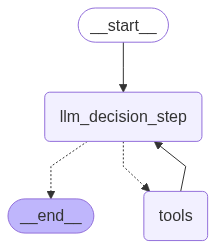

In [90]:
travel_plan_graph = builder.compile()

from IPython.display import Image, display
display(Image(travel_plan_graph .get_graph().draw_mermaid_png()))

In [92]:
message = [HumanMessage(content="I need to plan a trip to Paris during christmas holiday in 2025.")]

In [93]:
response  = travel_plan_graph.invoke({"messages": message})



In [ ]:
response

{'messages': [HumanMessage(content='I need to plan a trip to Paris during christmas holiday in 2025.', additional_kwargs={}, response_metadata={}, id='f5c5f5ba-df3e-430c-a7fe-1e5ecd3dbf8c'),
  AIMessage(content="I can help you plan your trip. First, please provide me with your budget, preferred currency, and any specific interests or preferences you have for your trip to Paris. Let's assume the dates are from December 24 to December 31, 2025.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--147cb0f7-3e91-4070-860c-7de92f6c7c20-0', usage_metadata={'input_tokens': 3147, 'output_tokens': 58, 'total_tokens': 4013, 'input_token_details': {'cache_read': 0}})]}

In [94]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

I need to plan a trip to Paris during christmas holiday in 2025.
================================== Ai Message ==================================
Tool Calls:
  generate_complete_travel_plan (a12caae3-9e91-47ca-8591-73299ac04178)
 Call ID: a12caae3-9e91-47ca-8591-73299ac04178
  Args:
    dates: 2025-12-22 to 2025-12-28
    num_days: 7.0
    budget: 2500.0
    city: Paris
    currency: USD
    user_preferences: sightseeing and holiday markets
================================= Tool Message =================================
Name: generate_complete_travel_plan

{
  "trip_overview": "Embark on a magical 7-day Christmas week adventure in Paris, the City of Light. This itinerary is perfectly timed from December 22nd to 28th, 2025, allowing you to experience the city's unparalleled holiday charm. Paris transforms into a winter wonderland with dazzling lights along the Champs-Élysées, enchanting window displays at 

In [82]:
# # Simple Test Queries for All Tools - No Exception Handling

# print("=== TESTING ALL TRAVEL PLANNING TOOLS ===\n")

# # Test 1: Basic Math Tools
# print("1. Testing Math Tools:")
# result_add = add.invoke({"a": 100.0, "b": 50.0})
# print(f"   add(100, 50) = {result_add}")

# result_multiply = multiply.invoke({"a": 25.0, "b": 7.0})
# print(f"   multiply(25, 7) = {result_multiply}")

# result_total_cost = calculate_total_cost.invoke({"per_day_cost": 150.0, "num_days": 5})
# print(f"   calculate_total_cost(150/day, 5 days) = {result_total_cost}")

# result_daily_budget = calculate_daily_budget.invoke({"total_cost": 2000.0, "num_days": 7})
# print(f"   calculate_daily_budget(2000 total, 7 days) = {result_daily_budget}")

# # Test 2: Currency Tools
# print("\n2. Testing Currency Tools:")
# exchange_rate = get_exchange_rate.invoke({"from_currency": "USD", "to_currency": "EUR"})
# print(f"   Exchange rate USD to EUR: {exchange_rate}")

# converted_amount = convert_currency.invoke({"amount": 1000.0, "from_currency": "USD", "to_currency": "EUR"})
# print(f"   Convert $1000 USD to EUR: {converted_amount}")

# # Test 3: Places Information
# print("\n3. Testing Places Tool:")
# places_result = get_places.invoke({"place": "Tokyo", "dates": "2025-12-20 to 2025-12-27"})
# print(f"   Places info for Tokyo (first 200 chars): {places_result[:200]}...")

# # Test 4: Weather Information
# print("\n4. Testing Weather Tool:")
# weather_result = get_weather.invoke({"city": "Tokyo", "dates": "2025-12-20 to 2025-12-27"})
# print(f"   Weather info for Tokyo (first 200 chars): {weather_result[:200]}...")

# # Test 5: Day Plan
# print("\n5. Testing Day Plan Tool:")
# day_plan_result = get_day_plan.invoke({
#     "city": "Tokyo",
#     "day_number": 1,
#     "attractions": "Tokyo Tower, Senso-ji Temple, Shibuya Crossing",
#     "weather": "Sunny, 15°C"
# })
# print(f"   Day plan for Tokyo Day 1 (first 200 chars): {day_plan_result[:200]}...")

# # Test 6: Full Itinerary
# print("\n6. Testing Full Itinerary Tool:")
# itinerary_result = create_full_itinerary.invoke({
#     "city": "Tokyo",
#     "dates": "2025-12-20 to 2025-12-27",
#     "num_days": 7,
#     "attractions": "Tokyo Tower, Senso-ji Temple, Mount Fuji, Akihabara",
#     "weather": "Winter weather, 5-15°C",
#     "budget": "$2000"
# })
# print(f"   Full itinerary for Tokyo (first 200 chars): {itinerary_result[:200]}...")

# # Test 7: Trip Summary
# print("\n7. Testing Trip Summary Tool:")
# trip_summary_result = create_trip_summary.invoke({
#     "city": "Tokyo",
#     "dates": "2025-12-20 to 2025-12-27",
#     "total_cost": 2000.0,
#     "currency": "USD",
#     "attractions": "Multiple temples, modern districts, Mount Fuji",
#     "weather": "Winter season, cool temperatures",
#     "itinerary": "7-day comprehensive plan",
#     "hotel_info": "Mid-range hotels in central Tokyo"
# })
# print(f"   Trip summary for Tokyo (first 200 chars): {trip_summary_result[:200]}...")

# # Test 8: Complete Travel Plan
# print("\n8. Testing Complete Travel Plan Tool:")
# complete_plan_result = generate_complete_travel_plan.invoke({
#     "city": "London",
#     "dates": "2025-12-15 to 2025-12-22",
#     "num_days": 7,
#     "budget": 1800.0,
#     "currency": "USD",
#     "user_preferences": "history, museums, traditional food"
# })
# print(f"   Complete travel plan for London (first 200 chars): {complete_plan_result[:200]}...")

# # Test 9: Currency Conversion Search
# print("\n9. Testing Currency Conversion Search:")
# currency_search_result = currency_conversion_search.invoke({
#     "amount": 500.0,
#     "from_currency": "USD",
#     "to_currency": "GBP"
# })
# print(f"   Currency search result (first 150 chars): {currency_search_result[:150]}...")

# # Test 10: Trip Summary Search
# print("\n10. Testing Trip Summary Search:")
# summary_search_result = generate_trip_summary_search.invoke({
#     "trip_data": "Tokyo trip, 7 days, $2000 budget, winter season, cultural attractions"
# })
# print(f"    Trip summary search result (first 200 chars): {summary_search_result[:200]}...")

# print("\n=== ALL TOOLS TESTED SUCCESSFULLY ===")
# print(f"Total tools tested: 10 different tools")
# print("All tools are working and returning results!")
# response  = travel_plan_graph.invoke({"messages": message})



In [96]:
# Streamlit Travel Planning Application
import streamlit as st
import json
from datetime import datetime, timedelta
import pandas as pd

def streamlit_travel_planner_app():
    """
    Streamlit application for travel planning that receives user queries
    and generates complete travel plans using the LangGraph workflow.
    """

    # App Configuration
    st.set_page_config(
        page_title="AI Travel Agent & Expense Planner",
        page_icon="✈️",
        layout="wide",
        initial_sidebar_state="expanded"
    )

    # Header
    st.title("🌍 AI Travel Agent & Expense Planner")
    st.markdown("**Plan your perfect trip with real-time data and intelligent recommendations**")
    st.divider()

    # Sidebar for user inputs
    with st.sidebar:
        st.header("📝 Trip Details")

        # Destination input
        destination = st.text_input(
            "Destination City",
            placeholder="e.g., Paris, Tokyo, New York",
            help="Enter the city you want to visit"
        )

        # Date inputs
        col1, col2 = st.columns(2)
        with col1:
            start_date = st.date_input(
                "Start Date",
                value=datetime.now() + timedelta(days=30),
                min_value=datetime.now().date()
            )
        with col2:
            end_date = st.date_input(
                "End Date",
                value=datetime.now() + timedelta(days=37),
                min_value=start_date
            )

        # Calculate number of days
        if start_date and end_date:
            num_days = (end_date - start_date).days
            st.info(f"Trip Duration: {num_days} days")

        # Budget input
        budget = st.number_input(
            "Total Budget",
            min_value=100,
            max_value=50000,
            value=2000,
            step=100,
            help="Enter your total budget for the trip"
        )

        # Currency selection
        currency = st.selectbox(
            "Currency",
            ["USD", "EUR", "GBP", "INR", "CAD", "AUD", "JPY"],
            index=0
        )

        # User preferences
        preferences = st.text_area(
            "Travel Preferences",
            placeholder="e.g., culture, food, museums, nature, adventure, nightlife",
            help="Describe your interests and what you'd like to experience"
        )

        # Generate plan button
        generate_plan = st.button("🚀 Generate Travel Plan", type="primary")

    # Main content area
    if generate_plan:
        if not destination:
            st.error("Please enter a destination city!")
            return

        if num_days <= 0:
            st.error("Please select valid travel dates!")
            return

        # Format dates for the query
        dates_formatted = f"{start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}"

        # Create user query
        user_query = f"""I need to plan a trip to {destination} from {dates_formatted}
        for {num_days} days with a budget of {budget} {currency}.
        My preferences are: {preferences if preferences else 'general sightseeing and cultural experiences'}."""

        # Display loading message
        with st.spinner("🔄 Planning your perfect trip... This may take a few moments."):

            try:
                # Create message for the travel planning graph
                message = [HumanMessage(content=user_query)]

                # Invoke the travel planning graph
                response = travel_plan_graph.invoke({"messages": message})

                # Extract the final response
                final_message = response["messages"][-1]

                # Display success message
                st.success("✅ Your travel plan is ready!")

                # Create tabs for different sections
                tab1, tab2, tab3, tab4 = st.tabs(["📋 Complete Plan", "💰 Budget", "📊 Summary", "🔧 Raw Data"])

                with tab1:
                    st.header("🗺️ Complete Travel Plan")

                    # Check if the response contains tool calls
                    if hasattr(final_message, 'tool_calls') and final_message.tool_calls:
                        st.info("🔧 The AI is using specialized tools to create your plan...")

                        # Display tool calls information
                        for i, tool_call in enumerate(final_message.tool_calls, 1):
                            with st.expander(f"Tool {i}: {tool_call['name']}"):
                                st.json(tool_call['args'])

                    # Display the main content
                    if hasattr(final_message, 'content') and final_message.content:
                        # Try to parse as JSON for better formatting
                        try:
                            json_content = json.loads(final_message.content)

                            # Display formatted sections
                            if 'trip_overview' in json_content:
                                st.subheader("🌟 Trip Overview")
                                st.write(json_content['trip_overview'])

                            if 'weather_forecast' in json_content:
                                st.subheader("🌤️ Weather Forecast")
                                weather = json_content['weather_forecast']
                                col1, col2 = st.columns(2)
                                with col1:
                                    st.write("**Current Weather:**", weather.get('current_weather', 'N/A'))
                                    st.write("**Temperature Range:**", weather.get('temperature_range', 'N/A'))
                                with col2:
                                    if 'recommendations' in weather:
                                        st.write("**Recommendations:**")
                                        for rec in weather['recommendations'][:3]:
                                            st.write(f"• {rec}")

                            if 'places_info' in json_content:
                                st.subheader("🏛️ Places & Attractions")
                                places = json_content['places_info']

                                col1, col2 = st.columns(2)
                                with col1:
                                    if 'attractions' in places:
                                        st.write("**Top Attractions:**")
                                        for attr in places['attractions'][:5]:
                                            st.write(f"• {attr}")
                                with col2:
                                    if 'restaurants' in places:
                                        st.write("**Recommended Restaurants:**")
                                        for rest in places['restaurants'][:5]:
                                            st.write(f"• {rest}")

                            # Display the complete JSON in a more readable format
                            st.json(json_content)

                        except json.JSONDecodeError:
                            # If not JSON, display as text
                            st.write(final_message.content)
                    else:
                        st.write("Planning in progress... Please check the other tabs for details.")

                with tab2:
                    st.header("💰 Budget Breakdown")

                    # Calculate budget breakdown
                    daily_budget = budget / num_days
                    accommodation = budget * 0.4
                    food = budget * 0.3
                    activities = budget * 0.2
                    transport = budget * 0.1

                    col1, col2 = st.columns(2)

                    with col1:
                        st.metric("Total Budget", f"{budget:,.0f} {currency}")
                        st.metric("Daily Budget", f"{daily_budget:.0f} {currency}")
                        st.metric("Trip Duration", f"{num_days} days")

                    with col2:
                        st.write("**Budget Allocation:**")
                        st.write(f"🏨 Accommodation (40%): {accommodation:,.0f} {currency}")
                        st.write(f"🍽️ Food & Dining (30%): {food:,.0f} {currency}")
                        st.write(f"🎯 Activities (20%): {activities:,.0f} {currency}")
                        st.write(f"🚌 Transportation (10%): {transport:,.0f} {currency}")

                    # Budget chart
                    budget_data = pd.DataFrame({
                        'Category': ['Accommodation', 'Food & Dining', 'Activities', 'Transportation'],
                        'Amount': [accommodation, food, activities, transport],
                        'Percentage': [40, 30, 20, 10]
                    })

                    st.bar_chart(budget_data.set_index('Category')['Amount'])

                with tab3:
                    st.header("📊 Trip Summary")

                    # Trip details
                    st.write(f"**Destination:** {destination}")
                    st.write(f"**Travel Dates:** {dates_formatted}")
                    st.write(f"**Duration:** {num_days} days")
                    st.write(f"**Budget:** {budget:,.0f} {currency}")
                    st.write(f"**Preferences:** {preferences if preferences else 'General travel'}")

                    # Generated on
                    st.write(f"**Generated on:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                    # Download option
                    if st.button("📥 Download Plan as JSON"):
                        plan_data = {
                            "destination": destination,
                            "dates": dates_formatted,
                            "duration_days": num_days,
                            "budget": budget,
                            "currency": currency,
                            "preferences": preferences,
                            "generated_on": datetime.now().isoformat(),
                            "plan_content": final_message.content if hasattr(final_message, 'content') else str(final_message)
                        }

                        st.download_button(
                            label="Download Travel Plan",
                            data=json.dumps(plan_data, indent=2),
                            file_name=f"travel_plan_{destination}_{start_date.strftime('%Y%m%d')}.json",
                            mime="application/json"
                        )

                with tab4:
                    st.header("🔧 Raw Response Data")
                    st.write("**Full AI Response:**")
                    st.write(final_message)

                    st.write("**Response Type:**", type(final_message).__name__)

                    if hasattr(final_message, 'content'):
                        st.write("**Content Length:**", len(final_message.content) if final_message.content else 0)

                    # Raw JSON display
                    st.json(vars(final_message))

            except Exception as e:
                st.error(f"❌ An error occurred while generating your travel plan: {str(e)}")
                st.write("Please try again with different parameters or check your internet connection.")

                # Display error details in expander
                with st.expander("Error Details"):
                    st.code(str(e))

    else:
        # Welcome screen when no plan is generated
        col1, col2, col3 = st.columns([1, 2, 1])

        with col2:
            st.image("https://via.placeholder.com/400x200/4CAF50/white?text=Travel+Planning",
                    caption="AI-Powered Travel Planning")

            st.markdown("""
            ### 🚀 How it works:
            1. **Enter your destination** and travel dates
            2. **Set your budget** and currency preference
            3. **Describe your interests** and travel style
            4. **Click Generate** to get your personalized plan

            ### ✨ What you'll get:
            - **Complete itinerary** with day-by-day activities
            - **Weather forecasts** and packing recommendations
            - **Budget breakdown** and cost estimates
            - **Local attractions** and restaurant suggestions
            - **Transportation options** and tips
            """)

# Run the Streamlit app (for notebook testing)
def run_streamlit_app():
    """Function to run the Streamlit app"""
    st.write("🎯 **Streamlit Travel Planner Function Created Successfully!**")
    st.write("To run the full application, use the following command in terminal:")
    st.code("streamlit run travel_planner_app.py")
    st.write("Or call `streamlit_travel_planner_app()` directly")

# Display info about the function
run_streamlit_app()

2025-08-03 16:16:11.418 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:11.454 
  command:

    streamlit run /opt/homebrew/Caskroom/miniconda/base/envs/agentic/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-08-03 16:16:11.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:11.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:11.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:11.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:11.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03

In [95]:
# Create Standalone Streamlit Application File

def create_streamlit_file():
    """
    Create a standalone Streamlit application file that can be run independently
    """

    streamlit_app_code = '''
import streamlit as st
import json
from datetime import datetime, timedelta
import pandas as pd
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Import required libraries for travel planning
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from typing import List, Optional, Dict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.utilities import OpenWeatherMapAPIWrapper
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
import requests

# Set up environment variables
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["OPENWEATHERMAP_API_KEY"] = os.getenv("OWM_key")

# Initialize LLM and tools
llm = ChatGoogleGenerativeAI(model='gemini-2.5-pro')
search = DuckDuckGoSearchRun()
weather_search = OpenWeatherMapAPIWrapper()

# [Include all your Pydantic models here - PlacesResponse, WeatherResponse, etc.]
class PlacesResponse(BaseModel):
    attractions: List[str] = Field(description="List of top tourist attractions")
    restaurants: List[str] = Field(description="List of recommended restaurants")
    activities: List[str] = Field(description="List of recommended activities")
    transportation: List[str] = Field(description="List of transportation options")
    summary: str = Field(description="Brief summary of the place")

class WeatherResponse(BaseModel):
    current_weather: str = Field(description="Current weather conditions")
    forecast: List[str] = Field(description="Weather forecast for travel dates")
    temperature_range: str = Field(description="Temperature range during travel")
    recommendations: List[str] = Field(description="Weather-based recommendations")

class DayPlan(BaseModel):
    day_number: int = Field(description="Day number of the trip")
    morning_activities: List[str] = Field(description="Morning activities")
    afternoon_activities: List[str] = Field(description="Afternoon activities")
    evening_activities: List[str] = Field(description="Evening activities")
    restaurants: Dict[str, str] = Field(description="Meal recommendations")
    transportation_tips: List[str] = Field(description="Transportation suggestions")
    weather_considerations: List[str] = Field(description="Weather-based tips")

class FullItinerary(BaseModel):
    destination: str = Field(description="Destination city")
    total_days: int = Field(description="Total number of days")
    daily_plans: List[DayPlan] = Field(description="Day-by-day detailed plans")
    emergency_contacts: List[str] = Field(description="Emergency contacts")
    local_tips: List[str] = Field(description="Local tips and cultural insights")
    budget_breakdown: Dict[str, str] = Field(description="Budget breakdown")

class CompleteTravelPlan(BaseModel):
    trip_overview: str = Field(description="Trip overview and highlights")
    weather_forecast: WeatherResponse = Field(description="Weather information")
    places_info: PlacesResponse = Field(description="Places and attractions")
    itinerary: FullItinerary = Field(description="Complete itinerary")
    budget_summary: Dict[str, str] = Field(description="Budget breakdown")
    practical_info: List[str] = Field(description="Practical travel information")
    final_checklist: List[str] = Field(description="Final travel checklist")

# Initialize parsers
complete_plan_parser = PydanticOutputParser(pydantic_object=CompleteTravelPlan)

# [Include your generate_complete_travel_plan tool here]
@tool
def generate_complete_travel_plan(city: str, dates: str, num_days: int, budget: float, currency: str, user_preferences: str = "") -> str:
    """Create a comprehensive travel plan"""
    prompt = f"""Create a comprehensive travel plan for {city} from {dates} for {num_days} days
    with budget {budget} {currency}. Preferences: {user_preferences}

    {complete_plan_parser.get_format_instructions()}"""

    try:
        response = llm.invoke(prompt)
        parsed_response = complete_plan_parser.parse(response.content)
        return parsed_response.model_dump_json(indent=2)
    except:
        return json.dumps({"trip_overview": f"Basic travel plan for {city}"})

# Set up tools and graph
tools = [generate_complete_travel_plan]
llm_with_tools = llm.bind_tools(tools)

def function_1(state: MessagesState) -> MessagesState:
    """LLM function for travel planning"""
    user_question = state["messages"]
    response = llm_with_tools.invoke(user_question)
    return {"messages": [response]}

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("llm_decision_step", function_1)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "llm_decision_step")
builder.add_conditional_edges("llm_decision_step", tools_condition)
builder.add_edge("tools", "llm_decision_step")

travel_plan_graph = builder.compile()

# Streamlit App
def main():
    st.set_page_config(
        page_title="AI Travel Agent & Expense Planner",
        page_icon="✈️",
        layout="wide"
    )

    st.title("🌍 AI Travel Agent & Expense Planner")
    st.markdown("**Plan your perfect trip with real-time data and AI recommendations**")

    # Sidebar inputs
    with st.sidebar:
        st.header("📝 Trip Details")

        destination = st.text_input("Destination City", placeholder="e.g., Paris, Tokyo")

        col1, col2 = st.columns(2)
        with col1:
            start_date = st.date_input("Start Date", value=datetime.now() + timedelta(days=30))
        with col2:
            end_date = st.date_input("End Date", value=datetime.now() + timedelta(days=37))

        num_days = (end_date - start_date).days if start_date and end_date else 0
        st.info(f"Trip Duration: {num_days} days")

        budget = st.number_input("Total Budget", min_value=100, value=2000, step=100)
        currency = st.selectbox("Currency", ["USD", "EUR", "GBP", "INR"])
        preferences = st.text_area("Travel Preferences", placeholder="culture, food, museums")

        generate_plan = st.button("🚀 Generate Travel Plan", type="primary")

    # Main content
    if generate_plan and destination and num_days > 0:
        dates_formatted = f"{start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}"

        user_query = f"""Plan a trip to {destination} from {dates_formatted}
        for {num_days} days with budget {budget} {currency}.
        Preferences: {preferences or 'general travel'}."""

        with st.spinner("Planning your trip..."):
            try:
                message = [HumanMessage(content=user_query)]
                response = travel_plan_graph.invoke({"messages": message})
                final_message = response["messages"][-1]

                st.success("✅ Your travel plan is ready!")

                # Display tabs
                tab1, tab2, tab3 = st.tabs(["📋 Travel Plan", "💰 Budget", "📊 Summary"])

                with tab1:
                    st.header("🗺️ Complete Travel Plan")
                    if hasattr(final_message, 'content') and final_message.content:
                        try:
                            json_content = json.loads(final_message.content)
                            st.json(json_content)
                        except:
                            st.write(final_message.content)

                with tab2:
                    st.header("💰 Budget Breakdown")
                    daily_budget = budget / num_days
                    st.metric("Daily Budget", f"{daily_budget:.0f} {currency}")

                    budget_data = {
                        'Accommodation (40%)': budget * 0.4,
                        'Food (30%)': budget * 0.3,
                        'Activities (20%)': budget * 0.2,
                        'Transport (10%)': budget * 0.1
                    }

                    for category, amount in budget_data.items():
                        st.write(f"{category}: {amount:.0f} {currency}")

                with tab3:
                    st.header("📊 Trip Summary")
                    st.write(f"**Destination:** {destination}")
                    st.write(f"**Dates:** {dates_formatted}")
                    st.write(f"**Duration:** {num_days} days")
                    st.write(f"**Budget:** {budget} {currency}")

            except Exception as e:
                st.error(f"Error: {str(e)}")

    elif generate_plan:
        st.error("Please enter destination and valid dates!")

if __name__ == "__main__":
    main()
'''

    # Write the file
    with open("streamlit_travel_planner.py", "w", encoding="utf-8") as f:
        f.write(streamlit_app_code)

    print("✅ Streamlit application file created: streamlit_travel_planner.py")
    print("📝 To run the app, use: streamlit run streamlit_travel_planner.py")

    return "streamlit_travel_planner.py"

# Create the file
filename = create_streamlit_file()
print(f"Streamlit app saved as: {filename}")

# Also create a simple test function
def test_streamlit_function():
    """Simple test of the travel planning functionality"""
    print("🧪 Testing travel plan generation...")

    # Test parameters
    test_city = "Paris"
    test_dates = "2025-12-20 to 2025-12-27"
    test_days = 7
    test_budget = 2000
    test_currency = "USD"
    test_preferences = "culture, food, museums"

    try:
        # Generate a simple travel plan
        result = generate_complete_travel_plan.invoke({
            "city": test_city,
            "dates": test_dates,
            "num_days": test_days,
            "budget": test_budget,
            "currency": test_currency,
            "user_preferences": test_preferences
        })

        print("✅ Test successful!")
        print(f"Generated plan preview: {result[:200]}...")
        return True

    except Exception as e:
        print(f"❌ Test failed: {e}")
        return False

# Run test
test_result = test_streamlit_function()

✅ Streamlit application file created: streamlit_travel_planner.py
📝 To run the app, use: streamlit run streamlit_travel_planner.py
Streamlit app saved as: streamlit_travel_planner.py
🧪 Testing travel plan generation...
✅ Test successful!
Generated plan preview: {
  "trip_overview": "This 7-day journey to Paris from December 20-27, 2025, is crafted for the discerning traveler with a passion for culture, food, and museums. Paris, the 'City of Light,' is a glob...


In [97]:
# Call the function directly in the notebook
streamlit_travel_planner_app()

2025-08-03 16:16:53.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 16:16:53.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar